In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Iris.csv")

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


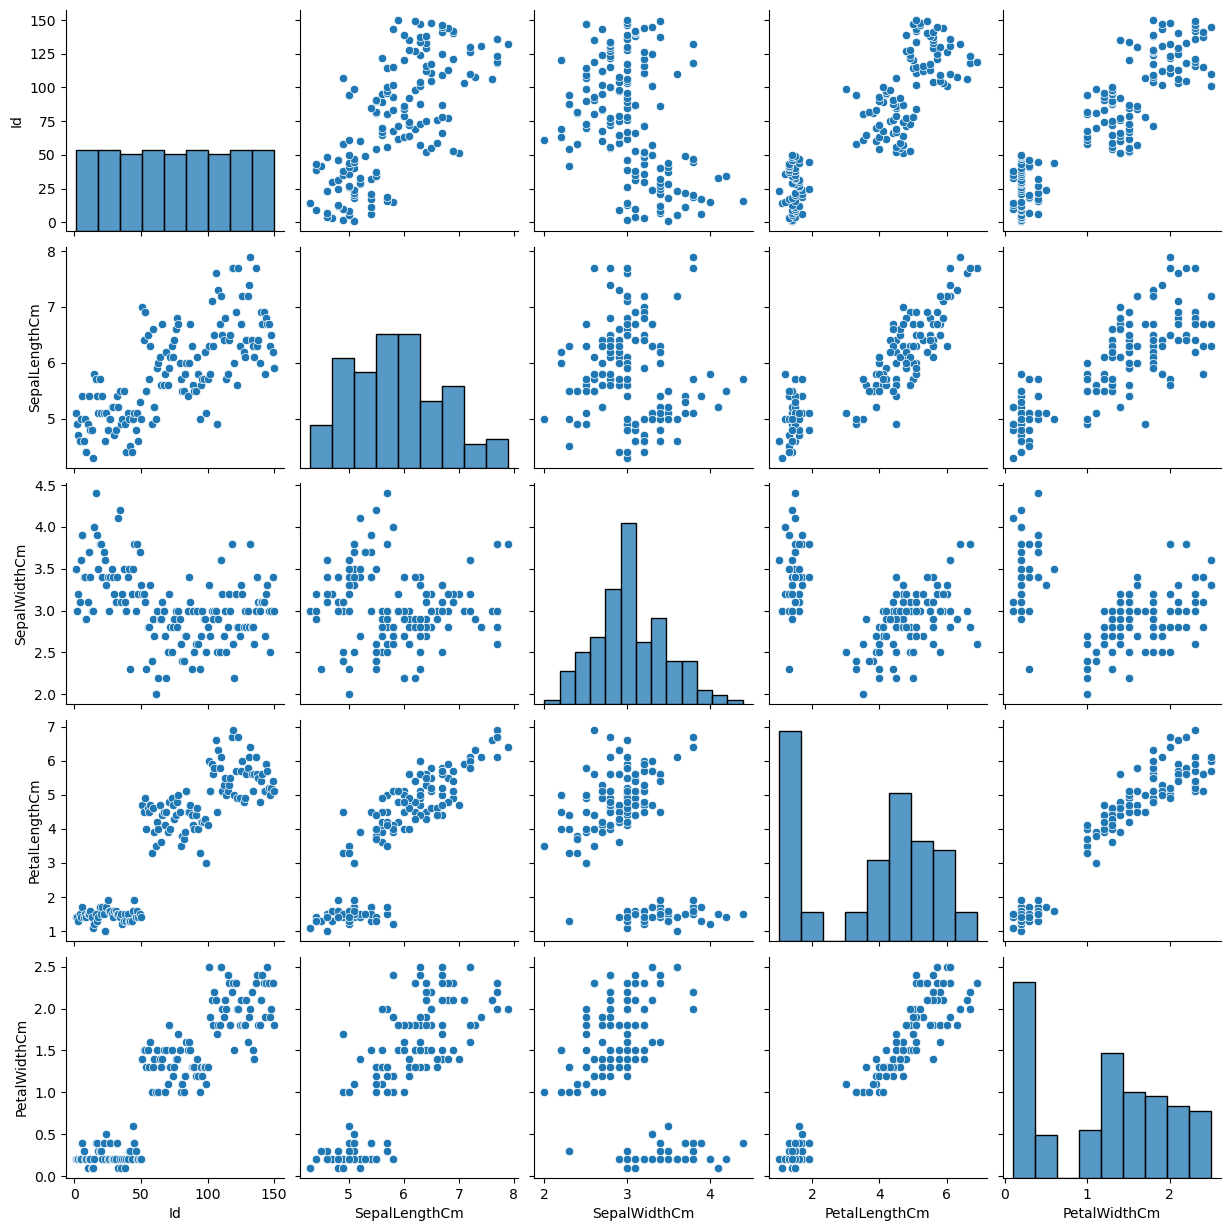

In [7]:
sns.pairplot(df)
plt.show()

In [10]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

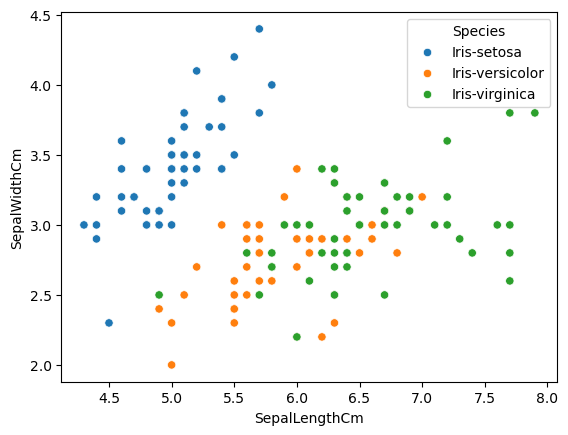

In [12]:
sns.scatterplot(x=df["SepalLengthCm"],y=df["SepalWidthCm"],hue=df["Species"])
plt.show()

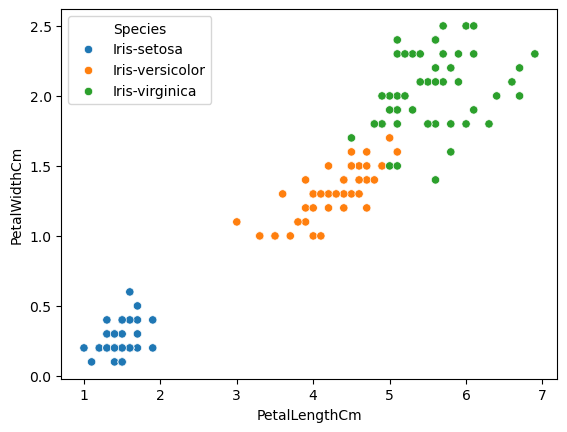

In [13]:
sns.scatterplot(x=df["PetalLengthCm"],y=df["PetalWidthCm"],hue=df["Species"])
plt.show()

In [14]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
df = df.drop("Id",axis=1)

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
label_encoder = LabelEncoder()
df["Species"] = label_encoder.fit_transform(df["Species"])

In [18]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [19]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [21]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [47]:
X = df.drop("Species",axis=1)
y = label_encoder.fit_transform(df["Species"])
isimler = label_encoder.classes_

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.naive_bayes import GaussianNB

In [29]:
gnb = GaussianNB()

In [30]:
gnb.fit(X_train_scaled,y_train)
y_pred = gnb.predict(X_test_scaled)

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [36]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test) )
print("classification report: l", classification_report(y_pred, y_test))

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy score:  1.0
classification report: l               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [ ]:
#Hyper parameter Tuning nedir ve gerekli mi bunlarda

In [41]:
# SVC Modeli
from sklearn.svm import SVC
svc_model = SVC(random_state=42)
svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [42]:
# Logistic Regression Modeli
from sklearn.linear_model import LogisticRegression
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [43]:
svc_predictions = svc_model.predict(X_test_scaled)
logreg_predictions = logreg_model.predict(X_test_scaled)

In [49]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [53]:
print("--- SVC MODELİ SONUÇLARI ---")
print(f"Doğruluk Skoru (Accuracy): {accuracy_score(y_test, svc_predictions):.4f}")
print("Sınıflandırma Raporu:")
print(classification_report(y_test, svc_predictions))

print("\n" + "="*40 + "\n")

print("--- LOGISTIC REGRESSION MODELİ SONUÇLARI ---")
print(f"Doğruluk Skoru (Accuracy): {accuracy_score(y_test, logreg_predictions):.4f}")
print("Sınıflandırma Raporu:")
print(classification_report(y_test, logreg_predictions))

print(confusion_matrix(y_test, svc_predictions))

--- SVC MODELİ SONUÇLARI ---
Doğruluk Skoru (Accuracy): 1.0000
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



--- LOGISTIC REGRESSION MODELİ SONUÇLARI ---
Doğruluk Skoru (Accuracy): 1.0000
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

[[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]


<Figure size 1000x800 with 0 Axes>

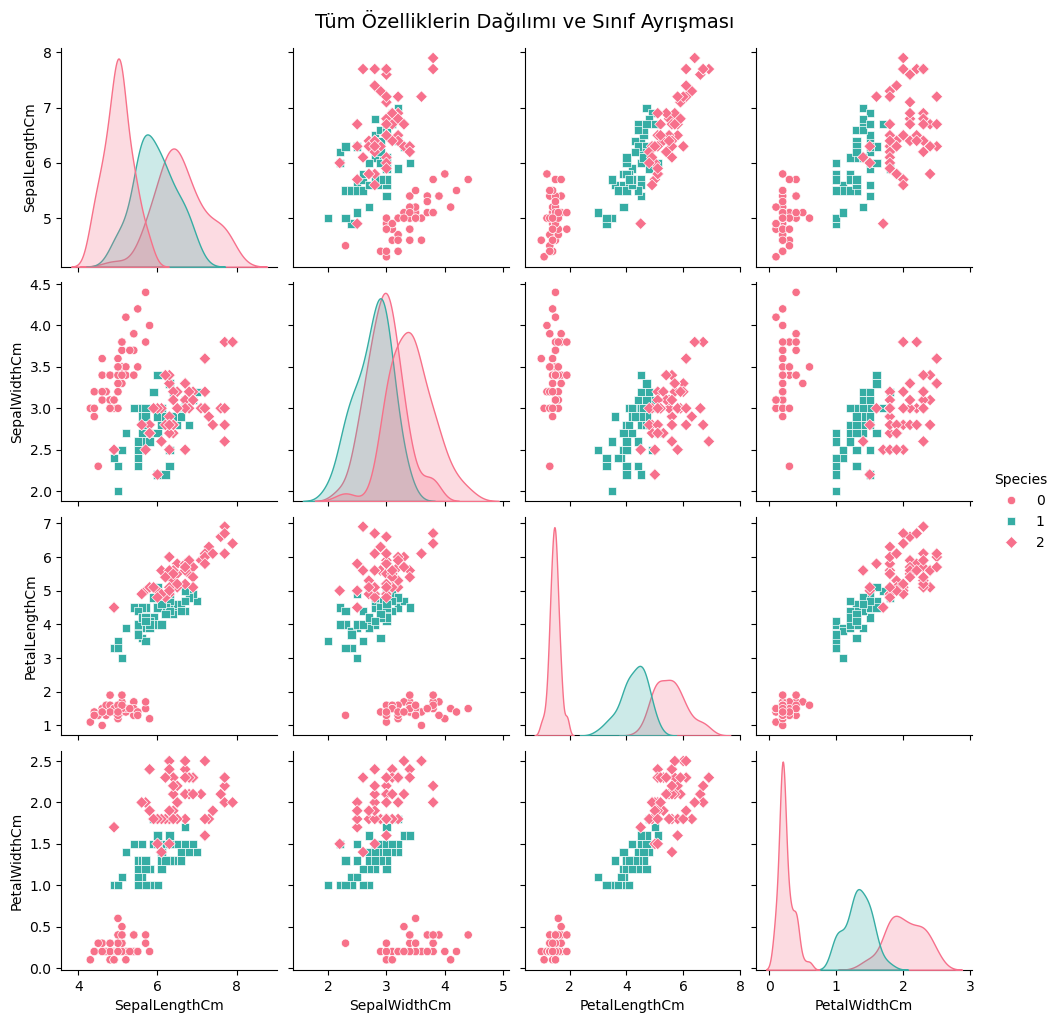

In [54]:
#Sınıf ayırdı için palet
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue="Species", palette="husl", markers=["o", "s", "D"])
plt.suptitle("Tüm Özelliklerin Dağılımı ve Sınıf Ayrışması", y=1.02, fontsize=14)
plt.show()

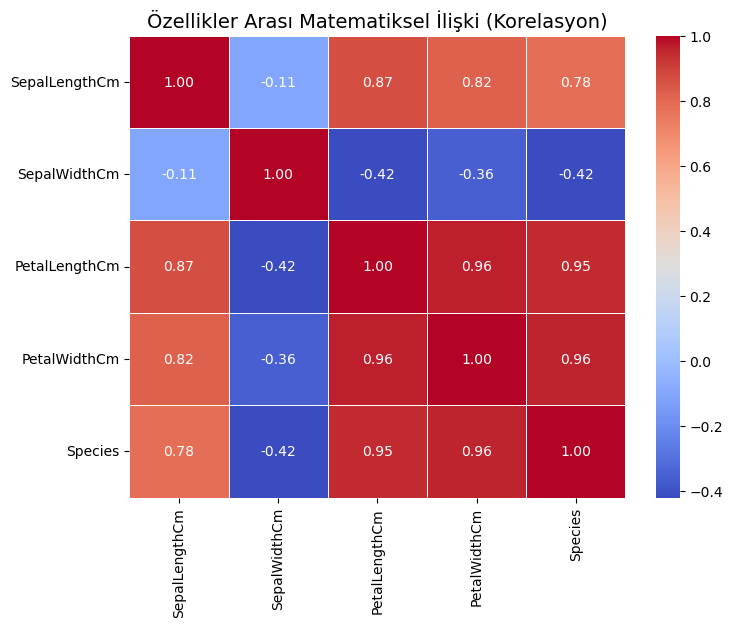

In [55]:
plt.figure(figsize=(8, 6))
# Korelasyon hesaplama ve ısı haritası çizdirme
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Özellikler Arası Matematiksel İlişki (Korelasyon)", fontsize=14)
plt.show()

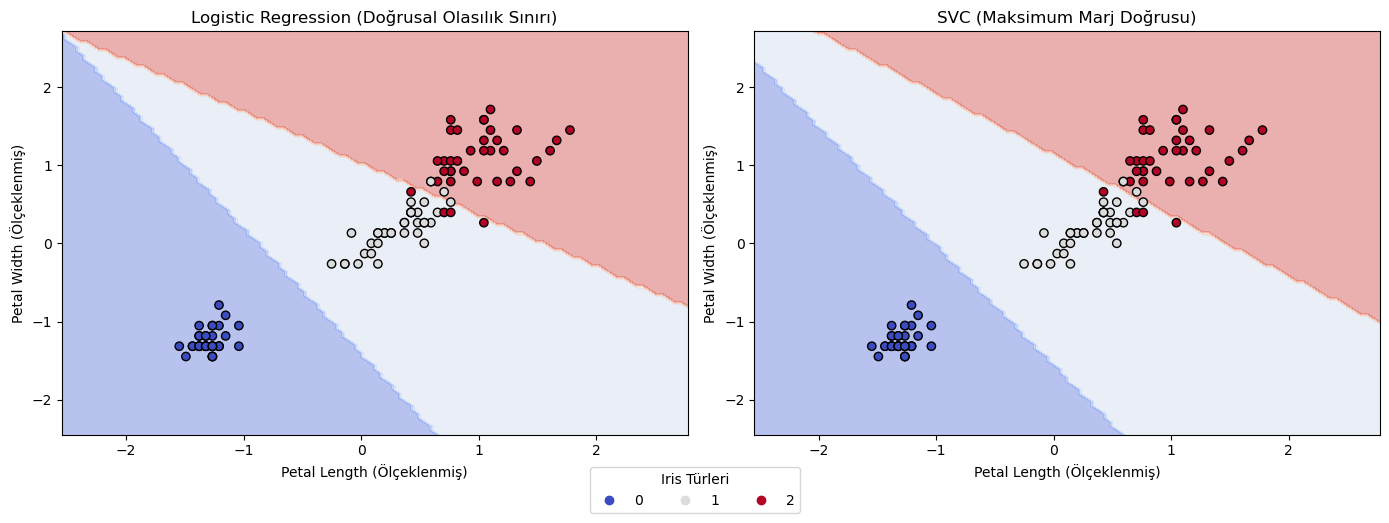

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay

# Görselleştirme için sadece Petal Length (indeks 2) ve Petal Width (indeks 3) alalım
X_train_2d = X_train_scaled[:, 2:4]

# Modelleri sadece bu iki özellikle yeniden eğitelim
# SVC'de marj mantığını net görmek için kernel'ı "linear" (doğrusal) olarak ayarlıyoruz
log_reg_2d = LogisticRegression(random_state=42)
svc_2d = SVC(kernel="linear", random_state=42)

log_reg_2d.fit(X_train_2d, y_train)
svc_2d.fit(X_train_2d, y_train)

# Yan yana iki grafik (subplot) oluşturalım
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grafik: Logistic Regression Karar Sınırı
DecisionBoundaryDisplay.from_estimator(
    log_reg_2d, X_train_2d, response_method="predict",
    cmap="coolwarm", alpha=0.4, ax=axes[0]
)
scatter_1 = axes[0].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="coolwarm", edgecolors="k")
axes[0].set_title("Logistic Regression (Doğrusal Olasılık Sınırı)")
axes[0].set_xlabel("Petal Length (Ölçeklenmiş)")
axes[0].set_ylabel("Petal Width (Ölçeklenmiş)")

# 2. Grafik: SVC Karar Sınırı
DecisionBoundaryDisplay.from_estimator(
    svc_2d, X_train_2d, response_method="predict",
    cmap="coolwarm", alpha=0.4, ax=axes[1]
)
scatter_2 = axes[1].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="coolwarm", edgecolors="k")
axes[1].set_title("SVC (Maksimum Marj Doğrusu)")
axes[1].set_xlabel("Petal Length (Ölçeklenmiş)")
axes[1].set_ylabel("Petal Width (Ölçeklenmiş)")

# Lejant (isimler değişkeninden gelir: Setosa, Versicolor, Virginica)
handles, labels = scatter_1.legend_elements()
fig.legend(handles, isimler, loc='lower center', ncol=3, title="Iris Türleri", bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()